# Playground — make your own charts

**How to use this notebook (in plain English):**

- A *notebook* is a list of boxes called **cells**. Each cell holds either text (like this one) or Python code.
- To **run** a code cell, click inside it and press **Shift + Enter**.
- Run the cells in order — top to bottom — the first time. After that you can re-run any cell at any time.
- To **change a chart**, edit the code inside the cell, then press Shift + Enter again. The chart updates.
- Don't worry about breaking anything. The CSV files on disk are read-only here; you can always restart.

**Tip:** If something looks wrong, click the menu *Kernel → Restart Kernel and Run All Cells*. That re-runs everything cleanly.

## Step 1 — Load the data

Run the cell below once. It loads all 5 CSV files into tables named `accounts`, `subs`, `usage`, `tickets`, `churn`.  
After that you don't need to load again — they stay in memory until you close the notebook.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path(r'C:\Users\Lenovo\OneDrive\Creative\Churn Study\data')

accounts = pd.read_csv(DATA / 'ravenstack_accounts.csv',       parse_dates=['signup_date'])
subs     = pd.read_csv(DATA / 'ravenstack_subscriptions.csv',  parse_dates=['start_date','end_date'])
usage    = pd.read_csv(DATA / 'ravenstack_feature_usage.csv',  parse_dates=['usage_date'])
tickets  = pd.read_csv(DATA / 'ravenstack_support_tickets.csv',parse_dates=['submitted_at','closed_at'])
churn    = pd.read_csv(DATA / 'ravenstack_churn_events.csv',   parse_dates=['churn_date'])

# Brand colors — feel free to use these in any chart below
BLUE, GREEN, ORANGE = '#2F9BFF', '#19C37D', '#FF6500'
BG, FG = '#0F1419', '#E6EDF3'

# Make every chart use a clean dark theme
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG, 'savefig.facecolor': BG,
    'axes.edgecolor': FG, 'axes.labelcolor': FG,
    'xtick.color': FG, 'ytick.color': FG, 'text.color': FG,
    'axes.titleweight': 'bold', 'axes.spines.top': False, 'axes.spines.right': False,
})

print('Loaded:')
print(f'  accounts: {accounts.shape[0]} rows, {accounts.shape[1]} columns')
print(f'  subs    : {subs.shape[0]} rows')
print(f'  usage   : {usage.shape[0]} rows')
print(f'  tickets : {tickets.shape[0]} rows')
print(f'  churn   : {churn.shape[0]} rows')

Loaded:
  accounts: 500 rows, 10 columns
  subs    : 5000 rows
  usage   : 25000 rows
  tickets : 2000 rows
  churn   : 600 rows


## Step 2 — Look at the data

`.head()` shows the first 5 rows of any table. Run the cell, then change `accounts` to `subs`, `usage`, `tickets`, or `churn` and re-run to peek at the other tables.

In [2]:
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


## Chart recipe 1 — Bar chart (counts by category)

**What this asks:** *How many customers do we have in each industry?*

**Try yourself:** change `'industry'` to `'country'`, `'plan_tier'`, or `'referral_source'`.

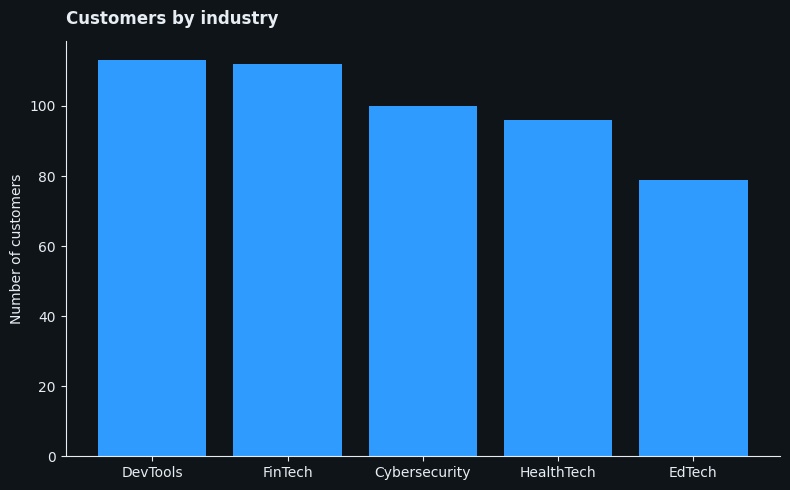

In [3]:
counts = accounts['industry'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(counts.index, counts.values, color=BLUE)
ax.set_title('Customers by industry', loc='left', pad=12)
ax.set_ylabel('Number of customers')
plt.tight_layout(); plt.show()

## Chart recipe 2 — Pie chart (share of a total)

**What this asks:** *Which acquisition channels bring in the customers?*

**Try yourself:** change `'referral_source'` to `'plan_tier'` or `'industry'`.

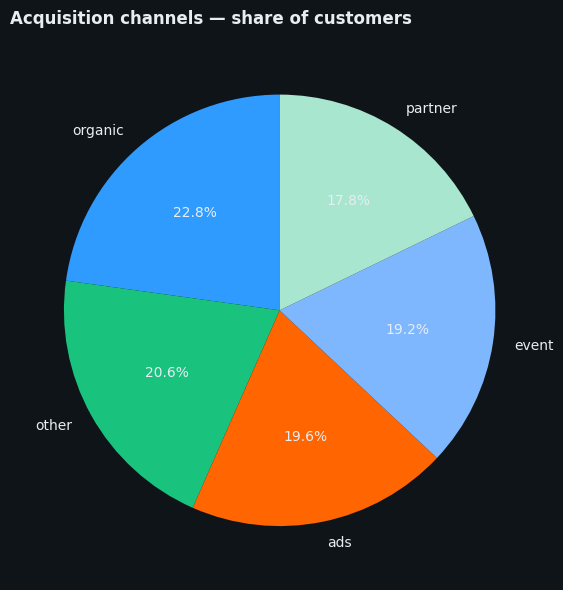

In [4]:
share = accounts['referral_source'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = [BLUE, GREEN, ORANGE, '#7FB7FF', '#A8E6CF']  # extras in case there are more slices
ax.pie(share.values, labels=share.index, colors=colors,
       autopct='%1.1f%%', startangle=90,
       textprops={'color': FG})
ax.set_title('Acquisition channels — share of customers', loc='left', pad=12)
plt.tight_layout(); plt.show()

## Chart recipe 3 — Line chart over time (signups per month)

**What this asks:** *How many new customers signed up each month?*

**Try yourself:** change `'ME'` (monthly) to `'W'` (weekly) or `'QE'` (quarterly).

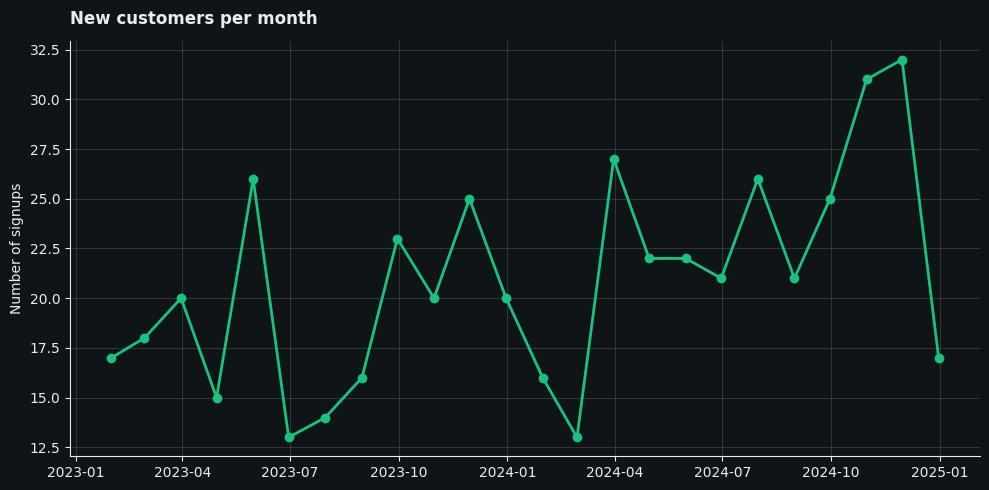

In [5]:
monthly_signups = accounts.set_index('signup_date').resample('ME').size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_signups.index, monthly_signups.values, marker='o', color=GREEN, linewidth=2)
ax.set_title('New customers per month', loc='left', pad=12)
ax.set_ylabel('Number of signups')
ax.grid(True, alpha=0.15, color=FG)
plt.tight_layout(); plt.show()

## Chart recipe 4 — Stacked bar (counts split by a second dimension)

**What this asks:** *In each industry, how many customers churned vs. stayed?*  
Blue = stayed, orange = churned.

**Try yourself:** change `'industry'` to `'country'` or `'plan_tier'`.

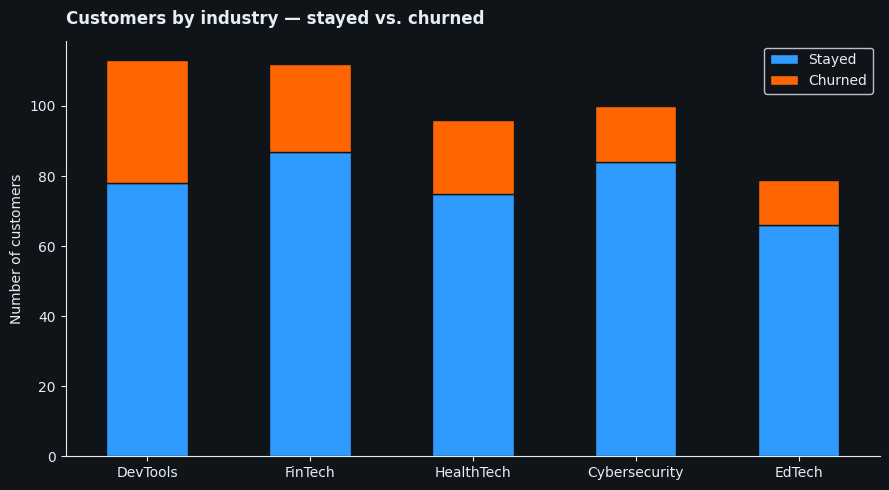

In [6]:
ct = pd.crosstab(accounts['industry'], accounts['churn_flag'])
ct = ct.rename(columns={False: 'Stayed', True: 'Churned'})
ct = ct.sort_values('Churned', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ct.plot(kind='bar', stacked=True, color=[BLUE, ORANGE], ax=ax, edgecolor=BG)
ax.set_title('Customers by industry — stayed vs. churned', loc='left', pad=12)
ax.set_ylabel('Number of customers')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(facecolor=BG, edgecolor=FG, labelcolor=FG)
plt.tight_layout(); plt.show()

## Chart recipe 5 — Histogram (distribution of one number)

**What this asks:** *How big are most customers, in seats?* The shape tells you if it's a few big whales or many small fish.

**Try yourself:** change `'seats'` to `subs['mrr_amount']` (monthly recurring revenue) — note the table name is `subs` not `accounts` here.

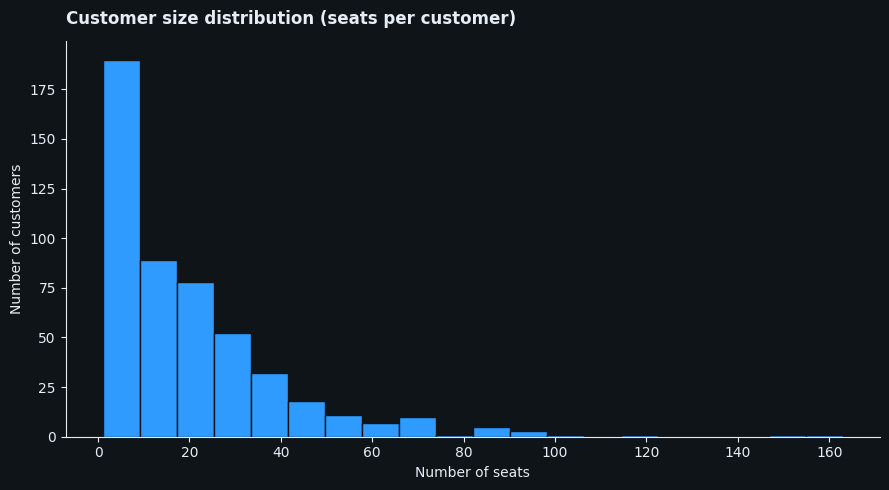

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(accounts['seats'], bins=20, color=BLUE, edgecolor=BG)
ax.set_title('Customer size distribution (seats per customer)', loc='left', pad=12)
ax.set_xlabel('Number of seats')
ax.set_ylabel('Number of customers')
plt.tight_layout(); plt.show()

## Chart recipe 6 — Scatter plot (two numbers compared)

**What this asks:** *Do bigger customers pay more?* (They should — but does the relationship look clean or noisy?)

**Try yourself:** change the x-axis or y-axis to other numeric columns in `subs`.

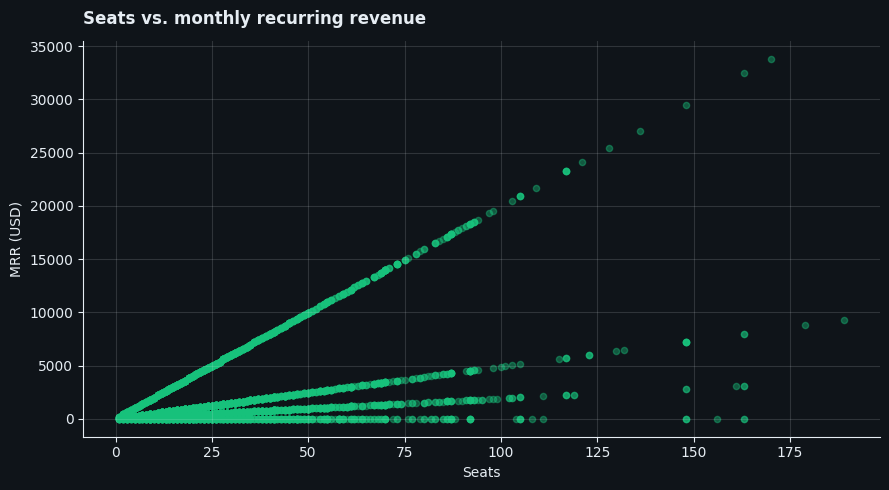

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(subs['seats'], subs['mrr_amount'], alpha=0.4, color=GREEN, s=20)
ax.set_title('Seats vs. monthly recurring revenue', loc='left', pad=12)
ax.set_xlabel('Seats')
ax.set_ylabel('MRR (USD)')
ax.grid(True, alpha=0.15, color=FG)
plt.tight_layout(); plt.show()

## Your turn — empty cell to write your own chart

Below is an empty code cell. Try copying one of the recipes above into it and changing one thing — a column name, a color, the chart title. Press **Shift + Enter** to see the result.

If you get stuck, ask me — paste the error message and we'll fix it.

In [9]:
# Your chart here



---
## Quick reference — the columns you can use

**accounts** — one row per customer  
`account_id, account_name, industry, country, signup_date, referral_source, plan_tier, seats, is_trial, churn_flag`

**subs** — subscription history (multiple rows per customer)  
`subscription_id, account_id, start_date, end_date, plan_tier, seats, mrr_amount, arr_amount, is_trial, upgrade_flag, downgrade_flag, churn_flag, billing_frequency, auto_renew_flag`

**usage** — daily product usage  
`usage_id, subscription_id, usage_date, feature_name, usage_count, usage_duration_secs, error_count, is_beta_feature`

**tickets** — support tickets  
`ticket_id, account_id, submitted_at, closed_at, resolution_time_hours, priority, first_response_time_minutes, satisfaction_score, escalation_flag`

**churn** — churn events (some are reactivations)  
`churn_event_id, account_id, churn_date, reason_code, refund_amount_usd, preceding_upgrade_flag, preceding_downgrade_flag, is_reactivation, feedback_text`